In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astropy import units as u
import glob

In [33]:
df_refreaction

,az_difference_arc_sec,el_difference_arc_sec,tel_azm_act,tel_elv_act,astropy_az,astropy_el,test_name,time,offset_time_seconds,astra_log_az,astra_log_el,log_diff_to_astropy_az_arc_sec,log_diff_to_astropy_el_arc_sec,mjd_astropy,mjd_astra,mjd_difference_seconds,time_dt
0,-0.5256,-131.0148,60.25117,15.04018,60.251024,15.003787,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 04:58:59,0,60.2469,15.0468,14.848138,-154.847127,61324.207627,61324.207627,0.000001,2026-10-11 04:58:59
1,-0.7092,-70.7724,51.44711,26.52087,51.446913,26.501211,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 05:58:59,0,51.4414,26.5268,19.847660,-92.118820,61324.249294,61324.249294,-0.000001,2026-10-11 05:58:59
2,-1.0116,-47.6676,39.63099,36.44900,39.630709,36.435759,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 06:58:59,0,39.6233,36.4539,26.673125,-65.308688,61324.290961,61324.290961,0.000004,2026-10-11 06:58:59
3,-1.4184,-36.7884,23.79366,43.78896,23.793266,43.778741,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 07:58:59,0,23.7836,43.7920,34.795954,-47.731939,61324.332627,61324.332627,0.000001,2026-10-11 07:58:59
4,-1.8180,-32.9940,4.17299,47.17862,4.172485,47.169455,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 08:58:59,0,4.1614,47.1791,39.906184,-34.723657,61324.374294,61324.374294,-0.000001,2026-10-11 08:58:59
5,-1.7892,-35.1972,343.72712,45.69845,343.726623,45.688673,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 09:58:59,0,343.7163,45.6962,37.163913,-27.097105,61324.415961,61324.415961,0.000004,2026-10-11 09:58:59
6,-1.4976,-43.6752,326.20498,39.77839,326.204564,39.766258,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 10:58:59,0,326.1964,39.7741,29.390372,-28.232675,61324.457627,61324.457627,0.000001,2026-10-11 10:58:59
7,-1.1052,-61.1676,312.86865,30.73915,312.868343,30.722159,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 11:58:59,0,312.8623,30.7335,21.753935,-40.825946,61324.499294,61324.499294,-0.000001,2026-10-11 11:58:59
8,-0.8172,-100.3068,302.99016,19.78498,302.989933,19.757117,setsource TEST_RA090_DEC020 -l 90.0 -b 20.0 -C...,2026-10-11 12:58:59,0,302.9854,19.7785,16.317773,-76.979364,61324.540961,61324.540961,0.000004,2026-10-11 12:58:59


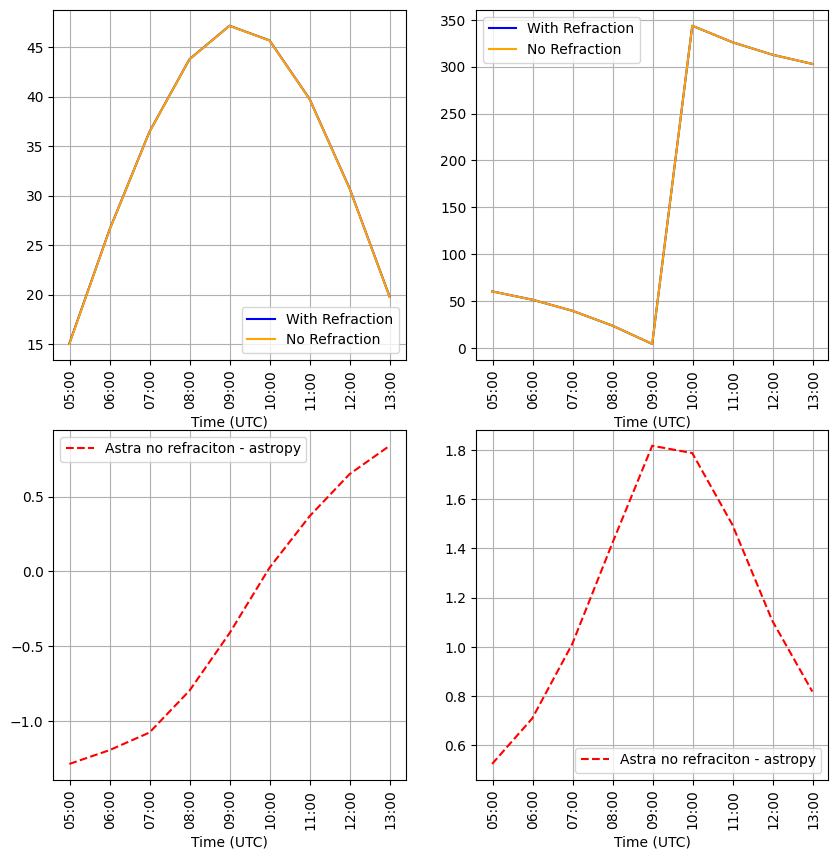

In [36]:
# refraction analysis
files = glob.glob("figures/astra_kosma_test_results_RA090*re*.xlsx")
df_no_refraction = pd.read_excel( "figures/astra_kosma_test_results_RA090_DEC020_with_no_refraction.xlsx" )
df_refraction = pd.read_excel( "figures/astra_kosma_test_results_RA090_DEC020_with_refraction.xlsx" )
# 
fig, ((ax_el,ax_az),(ax_el_res,ax_az_res)) = plt.subplots(2,2, figsize=(10,10))
# plot tel_elv_act from both files, convert time column to datetime
df_no_refraction["time"] = pd.to_datetime(df_no_refraction['time'])
df_refraction["time"] = pd.to_datetime(df_refraction['time'])
# plot tel_elv_act
ax_el.plot( pd.to_datetime(df_refraction['time']), df_refraction['tel_elv_act'], label='With Refraction', color='blue' )
ax_el.plot( pd.to_datetime(df_no_refraction['time']), df_no_refraction['tel_elv_act'], label='No Refraction', color='orange' )
# 
ax_az.plot( pd.to_datetime(df_refraction['time']), df_refraction['tel_azm_act'], label='With Refraction', color='blue' )
ax_az.plot( pd.to_datetime(df_no_refraction['time']), df_no_refraction['tel_azm_act'], label='No Refraction', color='orange' )
# convert residual to from degrees to arcseconds
#ax_el_res.plot( pd.to_datetime(df_refraction['time']), (df_refraction['tel_elv_act'] - df_no_refraction['tel_elv_act']) * 3600.0, label='Elv Diff (ref - noref) [arcsec]', color='green' )
#ax_az_res.plot( pd.to_datetime(df_refraction['time']), (df_refraction['tel_azm_act'] - df_no_refraction['tel_azm_act']) * 3600.0, label='Azm Diff (ref - noref) [arcsec]', color='green' )
# add in the residuls from astropy az,el, with column names astropy_az	astropy_el
ax_el_res.plot( pd.to_datetime(df_refraction['time']), (df_no_refraction['tel_elv_act'] - df_no_refraction['astropy_el']) * 3600.0, label='Astra no refraciton - astropy', color='red', linestyle='--' )
ax_az_res.plot( pd.to_datetime(df_refraction['time']), (df_no_refraction['tel_azm_act'] - df_no_refraction['astropy_az']) * 3600.0, label='Astra no refraciton - astropy', color='red', linestyle='--' )


# plot refraction correction from astropy
# rotate x tics and show  the hour and minute
for ax in [ax_el, ax_az, ax_el_res, ax_az_res]:
    ax.legend()
    ax.set_xlabel("Time (UTC)")
    # set time format on x axis to hour and minute
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))    
    ax.xaxis.set_tick_params(rotation=90)
    # set grid
    ax.grid(True)



In [56]:
## polar coords 

from astropy.time import Time
from astropy.utils import iers

# Load Earth orientation data
iers_a = iers.IERS_Auto.open()

obs_time = Time("2026-01-23 00:00:00")  # summer solstice
# print mjd
print(obs_time.mjd)
# Get polar motion (arcseconds)
xp, yp = iers_a.pm_xy(obs_time)
print(np.round(xp,4), np.round(yp,4))
# ut1-utc
dut1 = iers_a.ut1_utc(obs_time)
print(f"{xp.value:0.4f}\t{yp.value:0.4f}\t{dut1.value:0.5f}")

from astropy.coordinates.builtin_frames.utils import get_polar_motion
xp, yp = get_polar_motion(obs_time)




61063.0
0.0935 arcsec 0.346 arcsec
0.0935	0.3460	0.07266


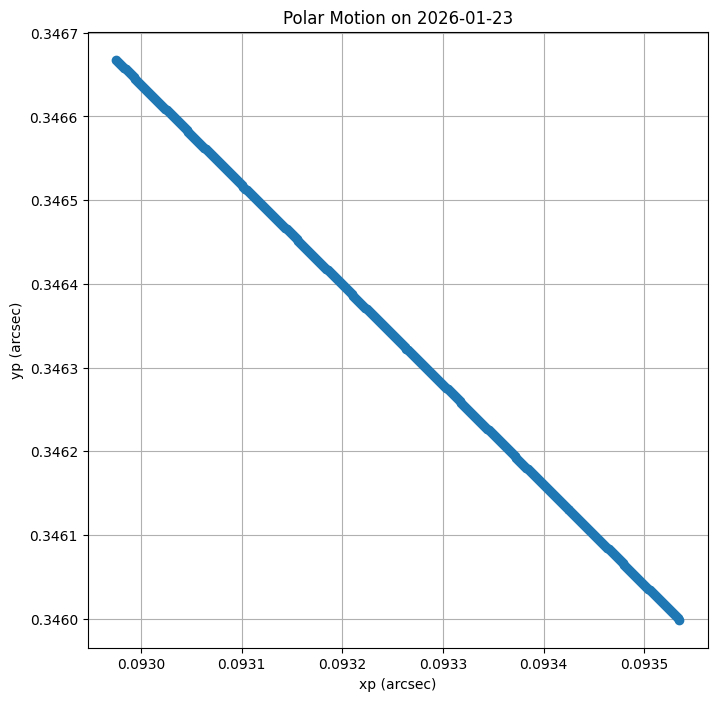

In [59]:
# plot px,py for a single day in 2026-01-23 in 5 min intervals
times = Time("2026-01-23 00:00:00") + np.arange(0, 24*60, 5) * u.min
xp, yp = iers_a.pm_xy(times)
fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.plot(xp, yp, marker='o')
ax.set_xlabel("xp (arcsec)")
ax.set_ylabel("yp (arcsec)")
ax.set_title("Polar Motion on 2026-01-23")
ax.grid(True)
plt.show()



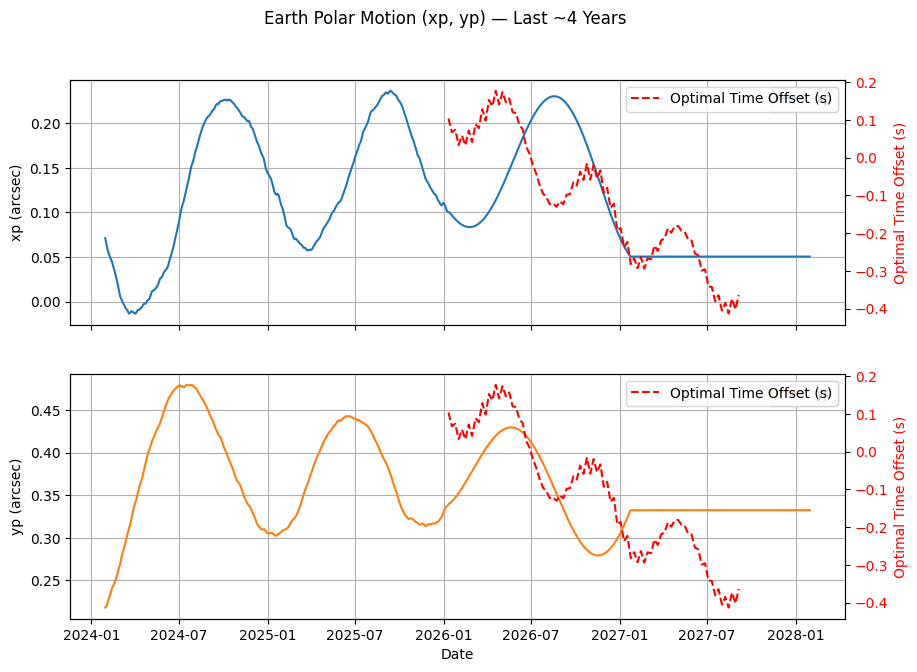

<Figure size 640x480 with 0 Axes>

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.utils import iers
from astropy.time import Time
from astropy import units as u  

# ------------------------------------------------------------------
# 1) Load full Earth orientation parameters (EOP) from IERS
# ------------------------------------------------------------------
# This will download (or open cached) IERS EOP finals data
iers_a = iers.IERS_Auto.open()

# ------------------------------------------------------------------
# 2) Make a time range for the last ~4 years
# ------------------------------------------------------------------
t_end = Time.now() + 2 * u.year  # add 0.5 days to ensure we get today's data if available
t_start = Time(t_end.utc.datetime.replace(year = t_end.utc.datetime.year - 4), scale="utc")

# Build daily times between t_start and t_end
times = Time(np.arange(t_start.jd, t_end.jd + 1), format="jd", scale="utc")

# ------------------------------------------------------------------
# 3) Extract polar motion (xp, yp)
# ------------------------------------------------------------------
# xp, yp returned as astropy Quantity in arcseconds
xp, yp = iers_a.pm_xy(times)

# ------------------------------------------------------------------
# 4) Make the plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax[0].plot(times.utc.datetime, xp.to('arcsec'), label="xp", color="tab:blue")
ax[0].set_ylabel("xp (arcsec)")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(times.utc.datetime, yp.to('arcsec'), label="yp", color="tab:orange")
ax[1].set_ylabel("yp (arcsec)")
ax[1].set_xlabel("Date")
ax[1].grid(True)
ax[1].legend()

fig.suptitle("Earth Polar Motion (xp, yp) — Last ~4 Years")


# over plot on a twinx 
# load time offeset data
df_time_offsets = pd.read_excel("astra_kosma_monthly_optimal_time_offsets_RA90_DEC22.xlsx")
df_time_offsets['time'] = pd.to_datetime(df_time_offsets['obstime'])
# overplot time and optimal_time_offset_seconds on twinx axis of the polar motion plot
ax2 = ax[0].twinx()
ax2.plot(df_time_offsets['time'], df_time_offsets['optimal_time_offset_seconds'], label='Optimal Time Offset (s)', color='red', linestyle='--')
ax2.set_ylabel('Optimal Time Offset (s)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

ax2 = ax[1].twinx()
ax2.plot(df_time_offsets['time'], df_time_offsets['optimal_time_offset_seconds'], label='Optimal Time Offset (s)', color='red', linestyle='--')
ax2.set_ylabel('Optimal Time Offset (s)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.show()

plt.tight_layout()
plt.show()


['astra_kosma_monthly_optimal_time_offsets_RA90_DEC20.xlsx', 'astra_kosma_monthly_optimal_time_offsets.xlsx', 'astra_kosma_monthly_optimal_time_offsets_RA-90_DEC-56.xlsx', 'astra_kosma_monthly_optimal_time_offsets_RA90_DEC22.xlsx', 'astra_kosma_monthly_optimal_time_offsets_RA90_DEC21.xlsx']
    optimal_time_offset_seconds  minimized_azimuth_residual_std_arcsec  \
0                      0.081944                               0.017980   
1                      0.031675                               0.026482   
2                      0.065114                               0.039345   
3                      0.113506                               0.045291   
4                      0.131070                               0.051513   
5                      0.072139                               0.059566   
6                     -0.053304                               0.067288   
7                     -0.161670                               0.050975   
8                     -0.138551           

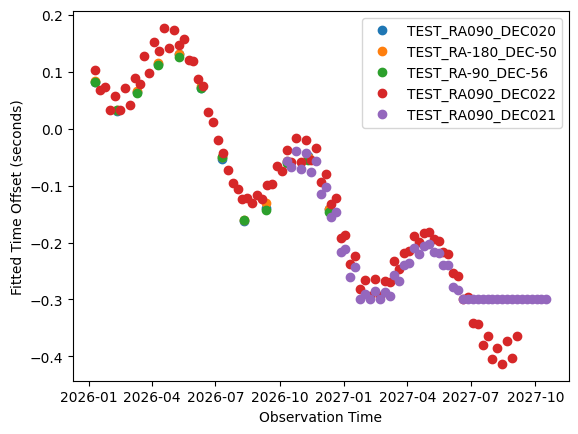

In [37]:
# load xlsx files with pandas
import pandas as pd
import matplotlib.pyplot as plt
import glob

# load differetn excel files and place in the same dataframe

files = glob.glob("astra_kosma_monthly_optimal_time_offsets*.xlsx")
print(files)
# 
fig, ax = plt.subplots()
for file in files:
    df = pd.read_excel(file)
    df["obstime"] = pd.to_datetime(df["obstime"])
    print(df)
    ax.plot_date(df["obstime"], df["optimal_time_offset_seconds"], "o",label=df["source"].iloc[0])
ax.legend()
ax.set_xlabel("Observation Time")
ax.set_ylabel("Fitted Time Offset (seconds)")
fig.savefig("optimal_time_offsets_all_sources.png")




## Claude test code

Calculating positions across 24 hours WITHOUT REFRACTION...
Location: -22.727200 deg, -67.331900 deg, 5600.0 m
Source: RA=180.000000°, Dec=-50.000000°
Date: 2026-01-10 00:00:00.000



At 16:00 UTC:
  ASTROPY:  Az=219.508282°, Alt=9.940170°
  PYSLALIB: Az=219.508396°, Alt=9.940413°
  OFFSET:   ΔAz=-0.411", ΔAlt=-0.876", |Δ|=0.968"

Statistics over 24 hours:
  ΔAz:  mean=-0.090", std=0.680", max=1.504"
  ΔAlt: mean=-0.235", std=0.542", max=0.922"
  |Δ|:  mean=0.873", max=1.516"

When source is above horizon:
  ΔAz:  mean=0.229", std=0.626"
  ΔAlt: mean=-0.227", std=0.612"
  |Δ|:  mean=0.889", max=1.516"

Plot saved to azimuth_comparison_no_refraction.png


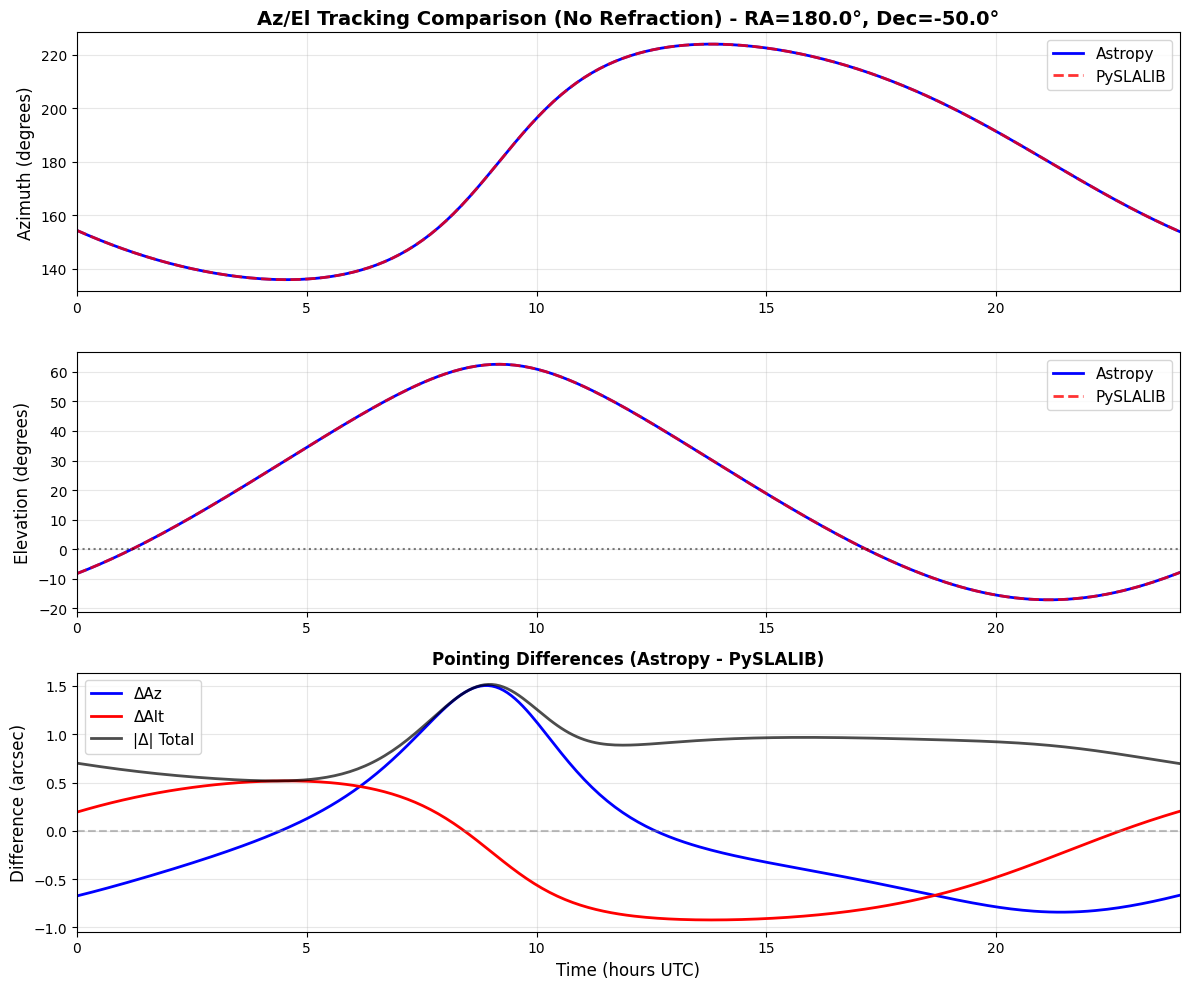

In [114]:
import numpy as np
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
try:
    import pyslalib.slalib as sla
except ImportError:
    import slalib as sla
import matplotlib.pyplot as plt

# Your input data
location = EarthLocation(x=2270350.84824463*u.m, 
                         y=-5435947.57157875*u.m, 
                         z=-2451045.99688049*u.m)
coord = SkyCoord(ra=180*u.deg, dec=-50*u.deg, frame='icrs')
base_time = Time('2026-01-10T00:00:00')

# Generate time array for full day (every 5 minutes)
n_points = 288  # 24 hours * 12 (5-min intervals)
time_offsets = np.linspace(0, 24, n_points)  # hours
times = base_time + time_offsets * u.hour

# Storage arrays
astropy_az = np.zeros(n_points)
astropy_alt = np.zeros(n_points)
pyslalib_az = np.zeros(n_points)
pyslalib_alt = np.zeros(n_points)

# Site parameters for pyslalib
lat = location.lat.rad
lon = location.lon.rad
height = location.height.value  # meters
temperature = 283.15  # 10°C in Kelvin
tlr = 0.0065  # tropospheric lapse rate K/m

# Convert RA/Dec to radians
ra_rad = coord.ra.rad
dec_rad = coord.dec.rad

print("Calculating positions across 24 hours WITHOUT REFRACTION...")
print(f"Location: {location.lat:.6f}, {location.lon:.6f}, {location.height:.1f}")
print(f"Source: RA={coord.ra.deg:.6f}°, Dec={coord.dec.deg:.6f}°")
print(f"Date: {base_time.iso}")
print()

for i, time in enumerate(times):
    # ===== ASTROPY CALCULATION (NO REFRACTION) =====
    # Turn off refraction with pressure=0
    altaz_frame = AltAz(obstime=time, location=location, pressure=0*u.bar)
    coord_altaz = coord.transform_to(altaz_frame)
    astropy_az[i] = coord_altaz.az.deg
    astropy_alt[i] = coord_altaz.alt.deg
    
    # ===== PYSLALIB CALCULATION (NO REFRACTION) =====
    mjd = time.mjd
    
    # Get mean to apparent place parameters
    amprms = sla.sla_mappa(2000.0, mjd)
    
    # Convert mean place to apparent place (includes precession, nutation, aberration)
    ra_app, dec_app = sla.sla_mapqk(ra_rad, dec_rad, 0.0, 0.0, 0.0, 0.0, amprms)
    
    # Get apparent to observed place parameters
    # Pressure=0 means no refraction
    aoprms = sla.sla_aoppa(mjd, 0.0, lon, lat, height,
                            0.0, 0.0,  # polar motion xp, yp
                            temperature, 0.0, 0.2,  # pressure=0 for no refraction
                            0.00055, tlr)
    
    # Convert apparent RA/Dec to observed Az/El
    az_rad, zen_rad, ha_rad, dec_obs, ra_obs = sla.sla_aopqk(ra_app, dec_app, aoprms)
    
    # Convert to degrees and normalize azimuth to 0-360
    az_deg = np.degrees(az_rad)
    if az_deg < 0:
        az_deg += 360.0
    pyslalib_az[i] = az_deg
    pyslalib_alt[i] = 90.0 - np.degrees(zen_rad)  # Convert zenith distance to altitude

# Calculate differences
diff_az = astropy_az - pyslalib_az
diff_alt = astropy_alt - pyslalib_alt
diff_total = np.sqrt(diff_az**2 + diff_alt**2)

# Handle azimuth wrap-around for plotting
diff_az_wrapped = np.where(diff_az > 180, diff_az - 360, diff_az)
diff_az_wrapped = np.where(diff_az_wrapped < -180, diff_az_wrapped + 360, diff_az_wrapped)

# Print statistics at the original time point (16:00)
idx_16 = np.argmin(np.abs(time_offsets - 16.0))
print(f"At 16:00 UTC:")
print(f"  ASTROPY:  Az={astropy_az[idx_16]:.6f}°, Alt={astropy_alt[idx_16]:.6f}°")
print(f"  PYSLALIB: Az={pyslalib_az[idx_16]:.6f}°, Alt={pyslalib_alt[idx_16]:.6f}°")
print(f"  OFFSET:   ΔAz={diff_az[idx_16]*3600:.3f}\", ΔAlt={diff_alt[idx_16]*3600:.3f}\", |Δ|={diff_total[idx_16]*3600:.3f}\"")
print()

print("Statistics over 24 hours:")
print(f"  ΔAz:  mean={np.mean(diff_az_wrapped)*3600:.3f}\", std={np.std(diff_az_wrapped)*3600:.3f}\", max={np.max(np.abs(diff_az_wrapped))*3600:.3f}\"")
print(f"  ΔAlt: mean={np.mean(diff_alt)*3600:.3f}\", std={np.std(diff_alt)*3600:.3f}\", max={np.max(np.abs(diff_alt))*3600:.3f}\"")
print(f"  |Δ|:  mean={np.mean(diff_total)*3600:.3f}\", max={np.max(diff_total)*3600:.3f}\"")

# Find where source is above horizon
above_horizon = astropy_alt > 0

if np.any(above_horizon):
    print(f"\nWhen source is above horizon:")
    print(f"  ΔAz:  mean={np.mean(diff_az_wrapped[above_horizon])*3600:.3f}\", std={np.std(diff_az_wrapped[above_horizon])*3600:.3f}\"")
    print(f"  ΔAlt: mean={np.mean(diff_alt[above_horizon])*3600:.3f}\", std={np.std(diff_alt[above_horizon])*3600:.3f}\"")
    print(f"  |Δ|:  mean={np.mean(diff_total[above_horizon])*3600:.3f}\", max={np.max(diff_total[above_horizon])*3600:.3f}\"")

# Create plots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: Azimuth comparison
axes[0].plot(time_offsets, astropy_az, 'b-', label='Astropy', linewidth=2)
axes[0].plot(time_offsets, pyslalib_az, 'r--', label='PySLALIB', linewidth=2, alpha=0.8)
axes[0].set_ylabel('Azimuth (degrees)', fontsize=12)
axes[0].set_title(f'Az/El Tracking Comparison (No Refraction) - RA={coord.ra.deg}°, Dec={coord.dec.deg}°', 
                 fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 24)

# Plot 2: Elevation comparison
axes[1].plot(time_offsets, astropy_alt, 'b-', label='Astropy', linewidth=2)
axes[1].plot(time_offsets, pyslalib_alt, 'r--', label='PySLALIB', linewidth=2, alpha=0.8)
axes[1].set_ylabel('Elevation (degrees)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle=':', alpha=0.5)
axes[1].set_xlim(0, 24)

# Plot 3: Differences
axes[2].plot(time_offsets, diff_az_wrapped*3600, 'b-', label='ΔAz', linewidth=2)
axes[2].plot(time_offsets, diff_alt*3600, 'r-', label='ΔAlt', linewidth=2)
axes[2].plot(time_offsets, diff_total*3600, 'k-', label='|Δ| Total', linewidth=2, alpha=0.7)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Time (hours UTC)', fontsize=12)
axes[2].set_ylabel('Difference (arcsec)', fontsize=12)
axes[2].set_title('Pointing Differences (Astropy - PySLALIB)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 24)


plt.tight_layout()
plt.savefig('/tmp/azimuth_comparison_no_refraction.png', dpi=150, bbox_inches='tight')
print(f"\nPlot saved to azimuth_comparison_no_refraction.png")


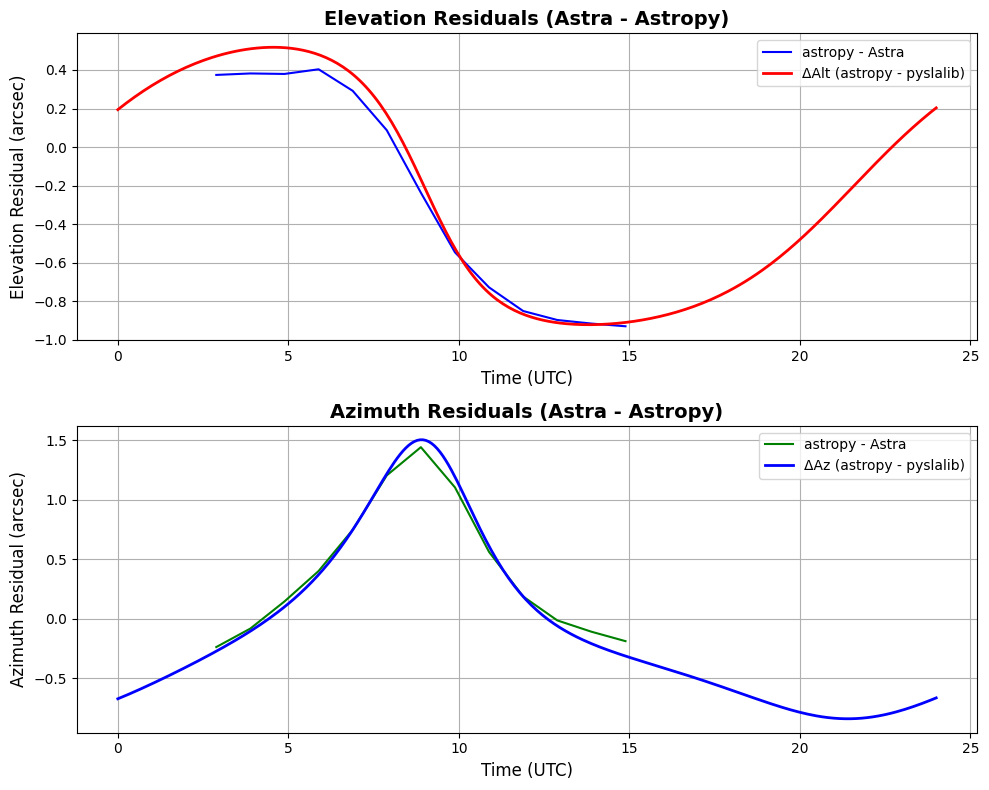

In [127]:
# load astra/astropy results from 
excel_file = "figures/astra_kosma_test_results_RA180_DEC-50.xlsx"
# load into pandas dataframe
df_results = pd.read_excel(excel_file)

# make a 2x1 plot comparing astra and astropy azimuth and elevation residuals
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
# Elevation residuals
# convert time column to hours in the day
df_results["time_dt"] = pd.to_datetime(df_results['time'])
df_results['hours_since_midnight'] = df_results['time_dt'].dt.hour + df_results['time_dt'].dt.minute / 60.0 + df_results['time_dt'].dt.second / 3600.0
axes[0].plot(df_results['hours_since_midnight'], (df_results['astropy_el'] - df_results['tel_elv_act']) * 3600.0, label='astropy - Astra', color='blue')
axes[0].set_title('Elevation Residuals (Astra - Astropy)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (UTC)', fontsize=12)
axes[0].set_ylabel('Elevation Residual (arcsec)', fontsize=12)
# change the time format on x axis to hour and minute
#axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
axes[0].legend()
axes[0].grid(True)
# Azimuth residuals
axes[1].plot(df_results['hours_since_midnight'], (df_results['astropy_az'] - df_results['tel_azm_act']) * 3600.0, label='astropy - Astra', color='green')
# plot pyslalib azimuth residuals as well

axes[1].set_title('Azimuth Residuals (Astra - Astropy)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (UTC)', fontsize=12)
axes[1].set_ylabel('Azimuth Residual (arcsec)', fontsize=12)
# change the time format on x axis to hour and minute
#axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
axes[1].legend()
axes[1].grid(True)
# look at slalib python azimuth residuals as well
# convert time_offset to datetime starting at base_time 
axes[1].plot(time_offsets, diff_az_wrapped*3600, 'b-', label='ΔAz (astropy - pyslalib)', linewidth=2)
axes[0].plot(time_offsets, diff_alt*3600, 'r-', label='ΔAlt (astropy - pyslalib)', linewidth=2)
# subtract astra from pyslalib from df_results['tel_azm_act'] using time_offsets to match time 
diff_astra_to_pyslalib_az = []
diff_astra_to_pyslalib_el = []
for t in df_results['hours_since_midnight']:
    # find closest time in time_offsets
    idx = (np.abs(time_offsets - t)).argmin()
    # calculate difference
    diff_az = (df_results.loc[df_results['hours_since_midnight'] == t, 'tel_azm_act'].values[0] - pyslalib_az[idx])
    diff_el = (df_results.loc[df_results['hours_since_midnight'] == t, 'tel_elv_act'].values[0] - pyslalib_alt[idx])
    diff_astra_to_pyslalib_az.append(diff_az)
    diff_astra_to_pyslalib_el.append(diff_el)
# plot these differences

#axes[1].plot(df_results['hours_since_midnight'], diff_astra_to_pyslalib_az, label='Astra - PySLALIB', color='orange')
#axes[0].plot(df_results['hours_since_midnight'], diff_astra_to_pyslalib_el, label='Astra - PySLALIB', color='orange')
#
axes[0].legend()
axes[1].legend()
fig.tight_layout()

In [125]:
df_results.loc[df_results['hours_since_midnight'] == t, 'tel_azm_act'].values[0], pyslalib_az[idx]
#pyslalib_az[idx]


(222.67195, 222.82080423831715)

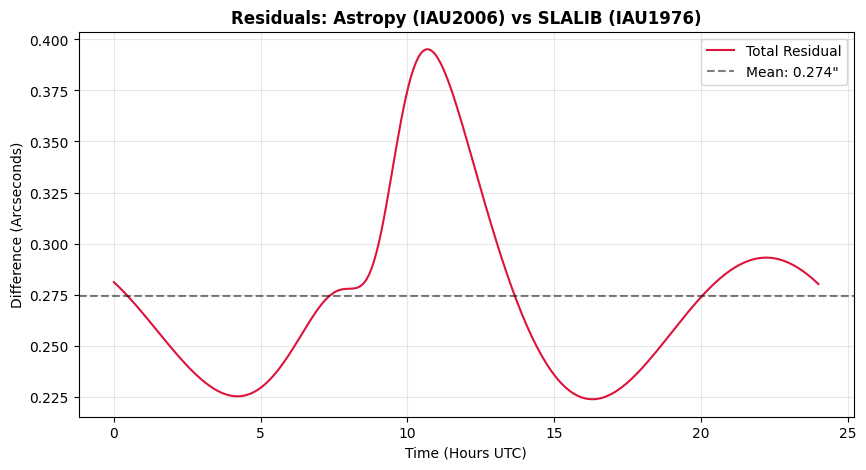

Residual Stats: Mean=0.2743", Max=0.3952"


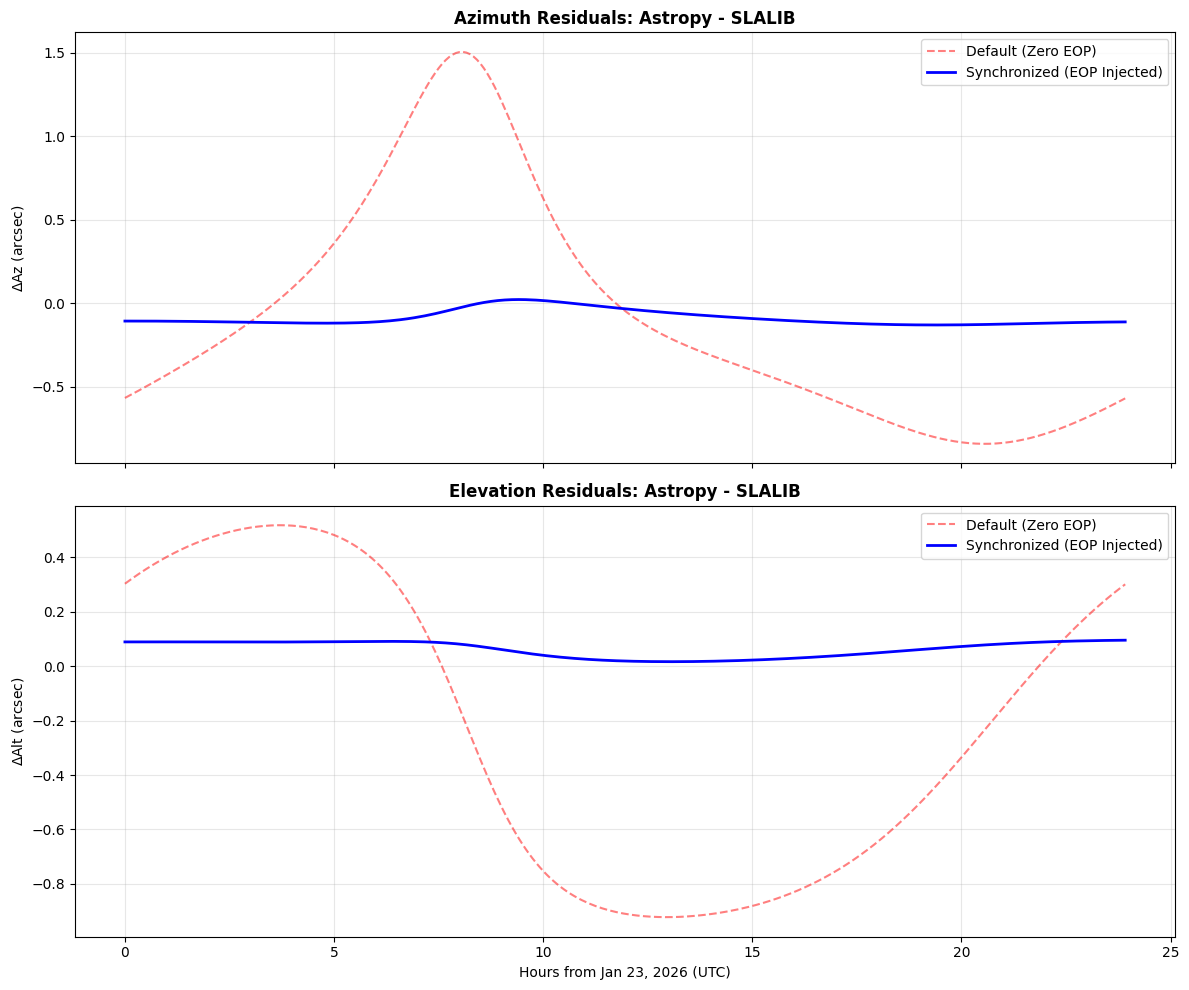

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from astropy.utils import iers

try:
    import pyslalib.slalib as sla
except ImportError:
    import slalib as sla

# --- 1. SETUP DATA ---
location = EarthLocation(x=2270350.84824463*u.m, 
                         y=-5435947.57157875*u.m, 
                         z=-2451045.99688049*u.m)
coord = SkyCoord(ra=180*u.deg, dec=-50*u.deg, frame='icrs')

base_time = Time('2026-01-23T00:00:00', scale='utc')
time_offsets = np.arange(0, 24*60, 5) * u.min
times = base_time + time_offsets

# --- 2. VECTORIZED EOP EXTRACTION ---
iers_a = iers.IERS_A.open()
xp, yp = iers_a.pm_xy(times)
dut1 = iers_a.ut1_utc(times)

xp_rad = xp.to(u.rad).value
yp_rad = yp.to(u.rad).value
dut1_val = dut1.to(u.s).value

# --- 3. CALCULATION LOOP ---
results = {
    'astropy': {'az': [], 'alt': []},
    'sla_default': {'az': [], 'alt': []},
    'sla_sync': {'az': [], 'alt': []}
}

for i, t in enumerate(times):
    # Astropy Reference
    altaz_frame = AltAz(obstime=t, location=location, pressure=0*u.bar)
    ast_res = coord.transform_to(altaz_frame)
    results['astropy']['az'].append(ast_res.az.deg)
    results['astropy']['alt'].append(ast_res.alt.deg)

    # Common Mean-to-Apparent (IAU 1976)
    ra_app, dec_app = sla.sla_map(coord.ra.rad, coord.dec.rad, 0, 0, 0, 0, 2000.0, t.mjd)

    # SLALIB Default (Zero EOP)
    aop_def = sla.sla_aoppa(t.mjd, 0.0, location.lon.rad, location.lat.rad, location.height.value,
                            0.0, 0.0, 283.15, 0.0, 0.0, 0.00055, 0.0065)
    az_def, zen_def, _, _, _ = sla.sla_aopqk(ra_app, dec_app, aop_def)
    results['sla_default']['az'].append(np.degrees(az_def) % 360.0)
    results['sla_default']['alt'].append(90.0 - np.degrees(zen_def))

    # SLALIB Synchronized (Injected EOP)
    aop_sync = sla.sla_aoppa(t.mjd, dut1_val[i], location.lon.rad, location.lat.rad, location.height.value,
                             xp_rad[i], yp_rad[i], 283.15, 0.0, 0.0, 0.00055, 0.0065)
    az_sync, zen_sync, _, _, _ = sla.sla_aopqk(ra_app, dec_app, aop_sync)
    results['sla_sync']['az'].append(np.degrees(az_sync) % 360.0)
    results['sla_sync']['alt'].append(90.0 - np.degrees(zen_sync))

# Convert to arrays for subtraction
for k in results:
    results[k]['az'] = np.array(results[k]['az'])
    results[k]['alt'] = np.array(results[k]['alt'])

# --- 4. RESIDUAL CALCULATION ---
def get_diff(az1, az2): return (az1 - az2 + 180) % 360 - 180

res_def_az = get_diff(results['astropy']['az'], results['sla_default']['az']) * 3600
res_sync_az = get_diff(results['astropy']['az'], results['sla_sync']['az']) * 3600
res_def_alt = (results['astropy']['alt'] - results['sla_default']['alt']) * 3600
res_sync_alt = (results['astropy']['alt'] - results['sla_sync']['alt']) * 3600

# --- 5. PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Azimuth Residuals
ax1.plot(time_offsets.to(u.hour), res_def_az, 'r--', alpha=0.5, label='Default (Zero EOP)')
ax1.plot(time_offsets.to(u.hour), res_sync_az, 'b-', lw=2, label='Synchronized (EOP Injected)')
ax1.set_ylabel('$\Delta$Az (arcsec)')
ax1.set_title('Azimuth Residuals: Astropy - SLALIB', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Elevation Residuals
ax2.plot(time_offsets.to(u.hour), res_def_alt, 'r--', alpha=0.5, label='Default (Zero EOP)')
ax2.plot(time_offsets.to(u.hour), res_sync_alt, 'b-', lw=2, label='Synchronized (EOP Injected)')
ax2.set_ylabel('$\Delta$Alt (arcsec)')
ax2.set_xlabel('Hours from Jan 23, 2026 (UTC)')
ax2.set_title('Elevation Residuals: Astropy - SLALIB', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

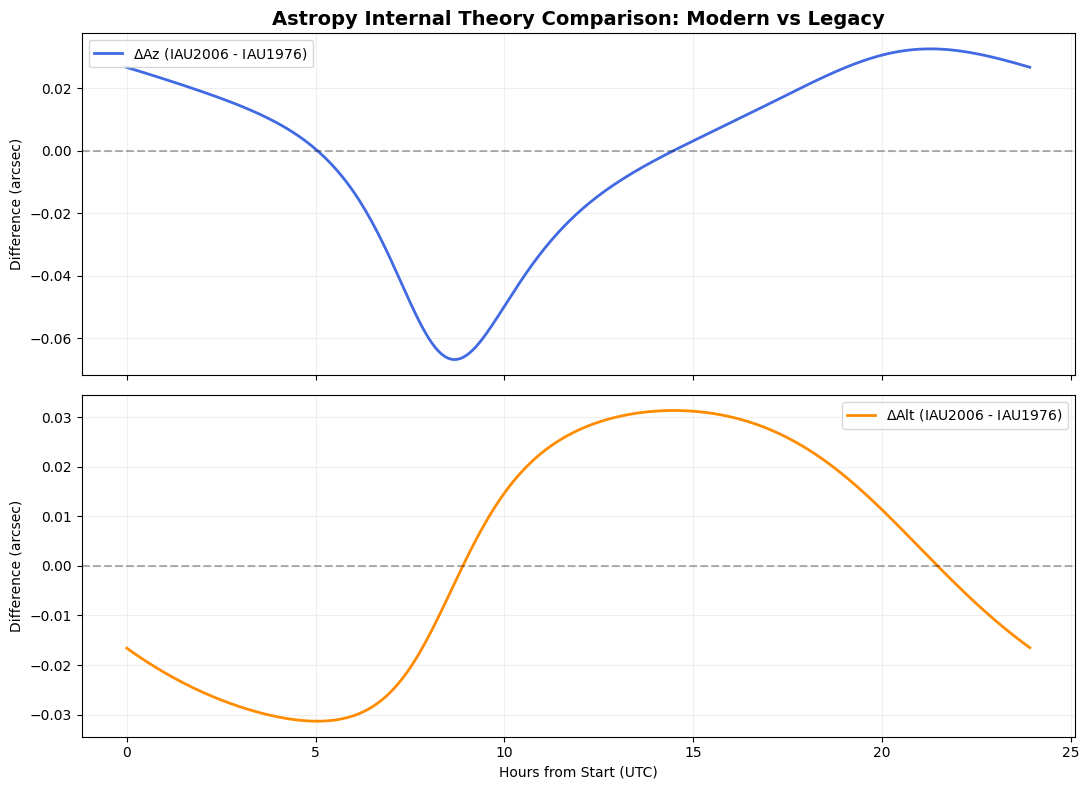

Mean Theory Gap: 0.0361 arcsec


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, FK5, ICRS
from astropy.time import Time
import astropy.units as u
from astropy.utils import iers

# --- 1. SETUP DATA ---
location = EarthLocation(x=2270350.84824463*u.m, 
                         y=-5435947.57157875*u.m, 
                         z=-2451045.99688049*u.m)

# Source at RA=180, Dec=-50
ra, dec = 180.0 * u.deg, -50.0 * u.deg

# Time array (24 hours)
base_time = Time('2026-01-23T00:00:00', scale='utc')
time_offsets = np.arange(0, 24*60, 5) * u.min
times = base_time + time_offsets

# Ensure common EOP usage for the entire session
# Astropy uses the current IERS-A table by default which provides XP, YP, and DUT1
iers_a = iers.IERS_A.open()

# --- 2. THE EXPERIMENT: IAU 2006 vs IAU 1976 ---

# Modern: ICRS -> AltAz (Uses IAU 2006/2000)
coord_modern = SkyCoord(ra=ra, dec=dec, frame='icrs')
altaz_modern = AltAz(obstime=times, location=location, pressure=0*u.bar)
pos_modern = coord_modern.transform_to(altaz_modern)

# Legacy: FK5 -> AltAz (Uses IAU 1976/1980)
# We define the same coordinates in the legacy FK5 frame (J2000 equinox)
coord_legacy = SkyCoord(ra=ra, dec=dec, frame='fk5', equinox='J2000')
pos_legacy = coord_legacy.transform_to(altaz_modern)

# --- 3. RESIDUAL CALCULATION ---
# Azimuth (corrected for wrap-around)
diff_az = (pos_modern.az - pos_legacy.az).wrap_at(180*u.deg).arcsec
# Elevation
diff_alt = (pos_modern.alt - pos_legacy.alt).arcsec

# --- 4. PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Azimuth Plot
ax1.plot(time_offsets.to(u.hour), diff_az, color='royalblue', lw=2, label='$\Delta$Az (IAU2006 - IAU1976)')
ax1.axhline(0, color='black', alpha=0.3, ls='--')
ax1.set_ylabel('Difference (arcsec)')
ax1.set_title('Astropy Internal Theory Comparison: Modern vs Legacy', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.2)

# Elevation Plot
ax2.plot(time_offsets.to(u.hour), diff_alt, color='darkorange', lw=2, label='$\Delta$Alt (IAU2006 - IAU1976)')
ax2.axhline(0, color='black', alpha=0.3, ls='--')
ax2.set_ylabel('Difference (arcsec)')
ax2.set_xlabel('Hours from Start (UTC)')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Mean Theory Gap: {np.mean(np.sqrt(diff_az**2 + diff_alt**2)):.4f} arcsec")

## Focal plane rotation analysis

In [ ]:

import math

def focalplane_offset(
    rot_dx, rot_dy,  # reference position of pixel [mm]
    angle_alpha,     # instrument focal plane rotation [deg]
    tel_angle_focal_plane,  # telescope focal plane angle [deg]
    rot_source_angle,       # source/rotator angle [deg]
    fp_plate_scale,         # plate scale [arcsec/mm]
    focal_length_correction, # instrument focal length correction [mm]
    port_name,              # e.g. "Left", "Right", "Cass"
    tel_elv_act,            # telescope elevation [deg]
    instr_flange_rotation=0 # only for Cass port [deg]
):
    # Constants
    M_PI = math.pi
    DEGRAD = math.pi / 180.0

    # Focal length calculation
    focal_length = (180.0 * 3600.0) / (fp_plate_scale * M_PI) + focal_length_correction

    # Instrument frame rotation (Nasmyth/Cass)
    if port_name.startswith("Left"):
        angle_if = -tel_elv_act
    elif port_name.startswith("Right"):
        angle_if = tel_elv_act
    elif port_name.startswith("Cass"):
        angle_if = instr_flange_rotation
    else:
        angle_if = 0.0

    # Commanded rotator angle
    rot_angle_cmd = angle_if + tel_angle_focal_plane + angle_alpha - rot_source_angle

    # Convert to radians for trigonometric functions
    angle_fp = -rot_angle_cmd
    angle_fp += angle_alpha
    angle_im = -angle_fp
    angle_fp += angle_if

    # Convert mm to arcsec
    rot_dx_arcsec = rot_dx / (focal_length * M_PI) * 180.0 * 3600.0
    rot_dy_arcsec = rot_dy / (focal_length * M_PI) * 180.0 * 3600.0

    # Final focal plane offsets (arcsec)
    fp_x = rot_dx_arcsec * math.cos(angle_fp * DEGRAD) - rot_dy_arcsec * math.sin(angle_fp * DEGRAD)
    fp_y = rot_dx_arcsec * math.sin(angle_fp * DEGRAD) + rot_dy_arcsec * math.cos(angle_fp * DEGRAD)

    return fp_x, fp_y  # Offset in arcseconds

# Example usage:
fp_x, fp_y = focalplane_offset(
     rot_dx=10.0, rot_dy=5.0,
     angle_alpha=2.0,
     tel_angle_focal_plane=1.0,
     rot_source_angle=0,
     fp_plate_scale=10.0,
     focal_length_correction=0.0,
     port_name="Left",
     tel_elv_act=45.0,
     instr_flange_rotation=0.0
 )
print("Sky offset (arcsec):", fp_x, fp_y)

Sky offset (arcsec): 100.85738983750332 48.24714411409122


## Astropy coordinate transformation with precession, nutation, aberration toggle on and off

In [51]:


import astropy.units as u
from astropy.coordinates import SkyCoord, ICRS, FK5, TETE, GCRS
from astropy.time import Time

# 1. Define target and time (using a future date to highlight shifts)
target_name = "Sirius"
c = SkyCoord.from_name(target_name)
c = SkyCoord(ra=180*u.deg, dec=-50*u.deg, frame='icrs')  # Ensure it's in ICRS for baseline
unix_time = 1776031202
obstime = Time(unix_time, format='unix', scale='utc')

print(f"Comparison for {target_name} at {obstime}\n" + "-"*60)

# 2. Level 0: No Corrections (ICRS) - Fixed Barycentric Frame
icrs_coord = c.transform_to(ICRS())

# 3. Level 1: Precession ONLY (FK5 Mean) - Long-term axial wobble
fk5_coord = c.transform_to(FK5(equinox=obstime))

# 4. Level 2: Precession + Nutation (TETE) - Includes short-term axial "shaking"
tete_coord = c.transform_to(TETE(obstime=obstime))

# 5. Level 3: Precession + Nutation + Aberration (GCRS) 
# GCRS is geocentric and accounts for light-bending due to Earth's orbital velocity
gcrs_coord = c.transform_to(GCRS(obstime=obstime))

# add in find altaz for each of these coordinates to see the difference in altitude as well
#altaz = c.transform_to(AltAz(obstime=obstime, location=EarthLocation(x=2270350.84824463*u.m, 
#                         y=-5435947.57157875*u.m, 
#                         z=-2451045.99688049*u.m)))

# --- Calculate the Offsets ---
def get_offset(c1, c2):
    return c1.separation(c2).to(u.arcsec).value

diff_precession = get_offset(icrs_coord, fk5_coord)
diff_nutation   = get_offset(fk5_coord, tete_coord)
diff_aberration = get_offset(tete_coord, gcrs_coord)
total_diff      = get_offset(icrs_coord, gcrs_coord)

# --- Display Results ---
results = [
    ["ICRS (Fixed)", icrs_coord, "Baseline"],
    ["FK5 (Precession)", fk5_coord, f"+{diff_precession:.8f}\" (Precession)"],
    ["TETE (Prec+Nut)", tete_coord, f"+{diff_nutation:.8f}\" (Nutation)"],
    ["GCRS (All Above+Aber)", gcrs_coord, f"+{diff_aberration:.8f}\" (Aberration)"],
]

fmt = "{:<20} | {:<12.6f} | {:<12.6f} | {:<20}"
print(f"{'Frame':<20} | {'RA (deg)':<12} | {'Dec (deg)':<12} | {'Correction Added'}")
print("-" * 80)
for name, coord, shift in results:
    print(fmt.format(name, coord.ra.deg, coord.dec.deg, shift))

print("-" * 80)
print(f"Total Cumulative Shift: {total_diff:.2f} arcseconds")


Comparison for Sirius at 1776031202.0
------------------------------------------------------------
Frame                | RA (deg)     | Dec (deg)    | Correction Added
--------------------------------------------------------------------------------
ICRS (Fixed)         | 180.000000   | -50.000000   | Baseline            
FK5 (Precession)     | 180.337232   | -50.146294   | +0.00000000" (Precession)
TETE (Prec+Nut)      | 180.343373   | -50.149923   | +0.00000000" (Nutation)
GCRS (All Above+Aber) | 180.007534   | -50.002957   | +0.00000000" (Aberration)
--------------------------------------------------------------------------------
Total Cumulative Shift: 0.00 arcseconds


In [47]:
c

<SkyCoord (ICRS): (ra, dec) in deg
    (101.28715533, -16.71611586)>

## ASTRA log summary table

In [ ]:
# load table into pandas from excel file
import pandas as pd
#df = pd.read_excel("astra_log_data_one_year.xlsx")
filenames = ["astra_log_data_start_june_2026.xlsx"]
filenames.append("astra_log_data_150_m50.xlsx")
filenames.append("astra_log_data_start_april_2026.xlsx")

filenames = ["astra_log_data.xlsx"]

#filenames.append("astra_log_data_sp_one_year.xlsx")
#filename = "astra_log_data.xlsx"
dfs = []
for file in filenames:
    print(f"Processing file: {file}")   
    dfs.append(pd.read_excel(file))
df = pd.concat(dfs, ignore_index=True)
#df = pd.read_excel("astra_log_data_sp_one_year.xlsx")
# residual between astropy and astra in arcseconds

# plot max/min residuals in azimuth and elevation as a function of time, with x axis in months
print(df.columns)


SyntaxError: incomplete input (943483551.py, line 104)

KeyError: 'astropy_az'

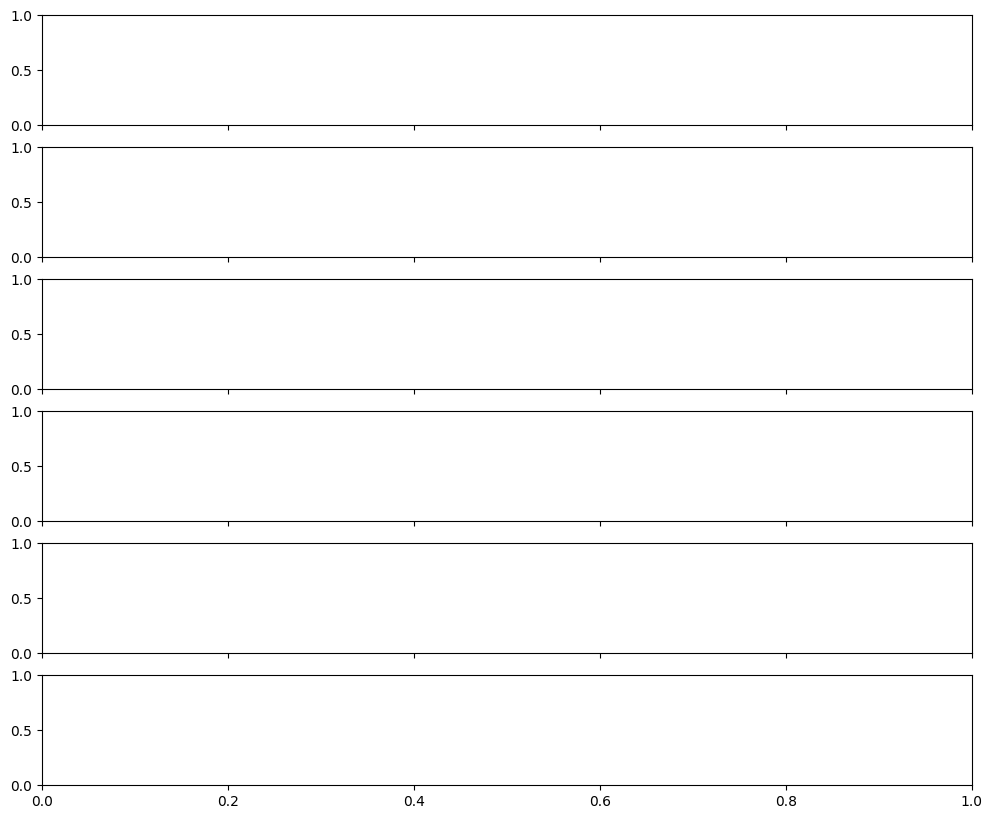

In [ ]:

# plot residuals as a function of time
fig, axes = plt.subplots(6, 1, figsize=(12, 10), sharex=True)
# plot az,el from both
axes[0].scatter(df["obs_time"], df["astropy_azimuth_deg"], label='Astropy Azimuth', marker="o")
axes[0].scatter(df["obs_time"], df["Az"], label='Astra Azimuth', marker="o")
axes[0].set_ylabel('Azimuth (deg)')
axes[0].legend()
axes[0].grid(True)
#
axes[1].scatter(df["obs_time"], df["astropy_elevation_deg"], label='Astropy Elevation', marker="o")
axes[1].scatter(df["obs_time"], df["El"], label='Astra Elevation', marker="o")
axes[1].set_ylabel('Elevation (deg)')
axes[1].legend()
axes[1].grid(True)


# plot az, ele residuals as well
axes[2].scatter(df["obs_time"], df["az_residual_arc_sec"], label='Azimuth Residual', marker="o")
axes[2].scatter(df["obs_time"], df["el_residual_arc_sec"], label='Elevation Residual', marker="o")
axes[2].set_ylabel('Pointing Residual\n(arcsec)')
axes[2].legend()
axes[2].grid(True)

axes[3].scatter(df["obs_time"], df["polmo_x_residual"], label='Polmo X Residual')
axes[3].scatter(df["obs_time"], df["polmo_y_residual"], label='Polmo Y Residual')
axes[3].set_ylabel('Polar Motion\nResidual (arcsec)')
axes[3].legend()
axes[3].grid(True)

# dut
axes[4].scatter(df["obs_time"], df["dut_residual"], label='DUT1 Residual',marker="o")
axes[4].set_ylabel('DUT1 Residual\n(seconds)')
axes[4].legend()
axes[4].grid(True)
# tdb
axes[5].scatter(df["obs_time"], df["del_tdb_residual"], label='DEL TDB Residual',marker="o")
axes[5].set_ylabel('DEL TDB Residual\n(seconds)')
axes[5].set_xlabel('Time')
axes[5].legend()
axes[5].grid(True)
fig.savefig(filenames[0].replace(".xlsx", ".png"), dpi=150, bbox_inches='tight')

# make a plot of the residuals in azimuth and elevation as a function of hours in the day
fig, ax = plt.subplots(figsize=(12, 6))
# convert obs_time to hours in the day
df["hours_in_day"] = df["obs_time"].dt.hour + df["obs_time"].dt.minute / 60.0 + df["obs_time"].dt.second / 3600
#
ax.scatter(df["hours_in_day"], df["az_residual_arc_sec"], label='Azimuth Residual', marker="o")
ax.scatter(df["hours_in_day"], df["el_residual_arc_sec"], label='Elevation Residual', marker="o")
ax.set_xlabel('Hours in Day (UTC)')
ax.set_ylabel('Pointing Residual\n(arcsec)')
ax.legend()
ax.grid(True)   
fig.savefig(filenames[0].replace(".xlsx", "_hours_in_day.png"), dpi=150, bbox_inches='tight')

# plot of astropy_tete_pre_nut_ra_deg, astropy_tete_pre_nut_dec_deg, astropy_gcrs_ra_deg, astropy_gcrs_dec_deg as a function of time
# plot az and el on different subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharex=True)
axes = axes.flatten()
axes[0].scatter(df["obs_time"], df["slaMapqk_RA"], label='SLALIB slaMapqk RA (deg)', marker="o")
axes[0].scatter(df["obs_time"], df["astropy_tete_pre_nut_ra_deg"], label='Astropy TETE Pre-Nut RA (deg)', marker="o")
# Ra axis
axes[0].set_ylabel('Right Ascension (deg)')
axes[0].set_xlabel('Time')
axes[0].legend()
axes[0].grid(True)
# Dec axis
axes[1].scatter(df["obs_time"], df["slaMapqk_Dec"], label='SLALIB slaMapqk Dec (deg)', marker="o")
axes[1].scatter(df["obs_time"], df["astropy_tete_pre_nut_dec_deg"], label='Astropy TETE Pre-Nut Dec (deg)', marker="o")
axes[1].set_ylabel('Declination (deg)')
axes[1].set_xlabel('Time')
axes[1].legend()
axes[1].grid(True)
# plot residuals
axes[2].scatter(df["obs_time"], df["astropy_tete_pre_nut_minus_slaMapqk_ra_deg"]*3600.0, label='Astropy . RA Residual (SLALIB - Astropy) (arcsec)', marker="o")
axes[2].set_ylabel('Residual (arcsec)')
axes[2].set_xlabel('Time')
axes[2].legend()
axes[2].grid(True)
# residual between astropy_gcrs_ra_deg and slaMapqk_Lam
axes[3].scatter(df["obs_time"], df["astropy_tete_pre_nut_minus_slaMapqk_dec_deg"]*3600.0, label='Astropy . DEC Residual (SLALIB - Astropy) (arcsec)', marker="o")
axes[3].set_ylabel('Residual (arcsec)')
axes[3].set_xlabel('Time')
axes[3].legend()
axes[3].grid(True)




# compare 



